In [1]:
import cooler
import cooltools
import bioframe as bf
import bbi
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ggner_3d.cm import CLR_CONNS, get_expected_cis_df, prepare_view_df
from ggner_3d.boundaries import preserved_boundaries_only, make_tads, assign_domain_score, get_insulation_fixed
from ggner_3d.dots_common import compare_loops_with_strength
from ggner_3d.bbi_helpers import stackup_bw_dict, stackup_bw_dict_q


NPROC = 6
resolution = 10000
window = 500_000
clr_ = CLR_CONNS(resolution)

# tad lengths
MAXLEN = 3e6
MINLEN = 1e5

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
import pandas as pd

def select_tads_by_level(df: pd.DataFrame, max_level: int) -> pd.DataFrame:
    """
    For each top-level (level 1) TAD:
      - return the deepest available children up to `max_level`
      - if no deeper child exists, return the parent TAD itself

    Assumes:
      - lower `tad_level` = larger domain (level 1 is the largest)
      - child TADs are nested within parent TADs
    """
    df = df.copy().reset_index(drop=True)

    # sort for stable output
    df = df.sort_values(["chrom", "start", "end", "tad_level"]).reset_index(drop=True)

    def get_children(row):
        """Get the next nested level of children inside `row`."""
        mask = (
            (df["chrom"] == row["chrom"]) &
            (df["tad_level"] > row["tad_level"]) &
            (df["tad_level"] <= max_level) &
            (df["start"] >= row["start"]) &
            (df["end"] <= row["end"]) &
            (
                (df["start"] > row["start"]) |  # strictly smaller on left
                (df["end"] < row["end"])       # or strictly smaller on right
            )
        )

        descendants = df.loc[mask]
        if descendants.empty:
            return descendants

        # only take the immediate next deeper level
        next_level = descendants["tad_level"].min()
        return descendants[descendants["tad_level"] == next_level]

    def collect(row):
        """Recursively collect deepest available TADs up to max_level."""
        if row["tad_level"] >= max_level:
            return [row.name]

        children = get_children(row)
        if children.empty:
            return [row.name]

        out = []
        for idx, child in children.iterrows():
            out.extend(collect(child))
        return out

    # start from level-1 TADs
    roots = df[df["tad_level"] == 1]

    selected_idx = []
    for idx, row in roots.iterrows():
        selected_idx.extend(collect(row))

    # keep unique rows in original sorted order
    selected_idx = sorted(set(selected_idx))
    return df.loc[selected_idx].reset_index(drop=True)

In [ ]:
inp = "/home/carlos/Clone/ggner-3d/ontad_out.coords.bed"
tads = pd.read_csv(inp, sep="\t")
tads['length'] = tads['end'] - tads['start']
tads = tads[(tads['tad_level'] == 1) & (tads['length'] >= MINLEN) & (tads['length'] <= MAXLEN)]
# tads = select_tads_by_level(tads, max_level=1)

In [ ]:
tads['start'] += 5000
tads['end'] -= 5000
tads

In [ ]:
expected_ = {k: get_expected_cis_df(k, resolution_kb=resolution//1000, label='chrom') for k in ['WTnoUV', 'WT3h']}
wtnouv_df = assign_domain_score(
                    tads,
                    clr=clr_['WTnoUV'],
                    expected=expected_['WTnoUV'],
                    view_df=prepare_view_df(arm=False),
                    resolution=resolution,
                    nproc=NPROC,
                    clr_weight_name='sweight'
                    )

wt3h_df = assign_domain_score(
                    tads,
                    clr=clr_['WT3h'],
                    expected=expected_['WT3h'],
                    view_df=prepare_view_df(arm=False),
                    resolution=resolution,
                    nproc=NPROC,
                    clr_weight_name='sweight'
                    )

tads_ds_merged = pd.merge(
    wtnouv_df[['chrom', 'start', 'end', 'domain_score']],
    wt3h_df[['chrom', 'start', 'end', 'domain_score']],
    on=['chrom', 'start', 'end'],
    suffixes=('_WTnoUV', '_WT3h')
)

In [ ]:
tads = tads_ds_merged.copy()
tads['ds_diff'] = tads['domain_score_WT3h'] / tads['domain_score_WTnoUV']

# drop na in ds_diff
tads = tads.dropna(subset=['ds_diff'])
tads['ds_diff_Q'] = pd.qcut(tads['ds_diff'], q=4, labels=False, duplicates='drop') + 1

In [ ]:
flank_ratio = 0.25
tads['flank_size'] = (tads['end'] - tads['start']) * flank_ratio
tads['flank_start'] = tads['start'] - tads['flank_size']
tads['flank_end'] = tads['end'] + tads['flank_size']

In [ ]:
dots_wt_nouv = pd.read_csv('/home/carlos/Clone/ggner-3d/data/dots/dots_WTnoUV_10000.csv')
dots_wt_3h = pd.read_csv('/home/carlos/Clone/ggner-3d/data/dots/dots_WT3h_10000.csv')


expected_wtnouv = get_expected_cis_df('WTnoUV', resolution_kb=resolution//1000, label='arm')
expected_wt3h = get_expected_cis_df('WT3h', resolution_kb=resolution//1000, label='arm')

view_df = prepare_view_df(arm=True)

loops_dict = compare_loops_with_strength(
    df_a=dots_wt_nouv,
    df_b=dots_wt_3h,
    clr_a=clr_['WTnoUV'],
    clr_b=clr_['WT3h'],
    expected_a=expected_wtnouv,
    expected_b=expected_wt3h,
    view_df_a=view_df,
    view_df_b=view_df,
    resolution=resolution,
    clustering_radius=20000,
    flank=100000,
    clr_weight_name='sweight',
    nproc=NPROC,
    sample_a_name='WTnoUV',
    sample_b_name='WT3h',
    compute_strength=False,
)

loops = loops_dict['common_loops'].copy()
loops['chrom'] = loops['chrom1_WTnoUV']
loops['start'] = loops['start1_WTnoUV']
loops['end'] = loops['end2_WTnoUV']

# loops = pd.read_csv('/home/carlos/Clone/ggner-3d/data/dots/dots_WTnoUV_10000.csv')
# loops['chrom'] = loops['chrom1']
# loops['start'] = loops['start1']
# loops['end'] = loops['end2']

loops['length'] = loops['end'] - loops['start']
overlap = bf.overlap(loops[['chrom', 'start', 'end', 'length']], tads[['chrom', 'start', 'end', 'ds_diff_Q']], suffixes=('_loop', '_tad'), return_overlap=True).dropna(subset=['overlap_start'])
overlap['overlap_length'] = overlap['overlap_end'] - overlap['overlap_start']
overlap['loop_overlap_fraction'] = overlap['overlap_length'] / overlap['length_loop']
overlap = overlap.loc[overlap.loop_overlap_fraction >= 0.9]
overlap['Q_contribution'] = overlap['loop_overlap_fraction'] * overlap['ds_diff_Q_tad']
loop_q = overlap.groupby(['chrom_loop', 'start_loop', 'end_loop'], as_index=False)['Q_contribution'].mean()
loop_q['Q'] = [round(i) for i in loop_q.Q_contribution]
loop_q = loop_q.loc[loop_q.Q.isin([1,2,3,4])].reset_index(drop=True)

loops = loop_q.copy()
loops.rename(columns={'chrom_loop': 'chrom', 'start_loop': 'start', 'end_loop': 'end'}, inplace=True)
loops['flank_size'] = loops['end'] - loops['start']
loops['flank_start'] = loops['start'] - loops['flank_size'] * flank_ratio
loops['flank_end'] = loops['end'] + loops['flank_size'] * flank_ratio
loops.Q = pd.Categorical(loops.Q, categories=[1,2,3,4], ordered=True)

# sample rows wrt min numbered Q category
n_rows_per_category = loops.Q.value_counts().min()
loops = loops.groupby('Q').apply(lambda x: x.sample(n_rows_per_category, random_state=42)).reset_index(drop=True)
loops.Q.value_counts()

loops_full_common = loops_dict['common_loops'].copy()
loops_full_common['chrom'] = loops_full_common['chrom1_WTnoUV']
loops_full_common['start'] = loops_full_common['start1_WTnoUV']
loops_full_common['end'] = loops_full_common['end2_WTnoUV']
loops_full_common['length'] = loops_full_common['end'] - loops_full_common['start']
loops_full_common['flank_start'] = loops_full_common['start'] - loops_full_common['length'] * flank_ratio
loops_full_common['flank_end'] = loops_full_common['end'] + loops_full_common['length'] * flank_ratio
loops_full_common.shape

In [ ]:
# data paths

# CTCF

ctcf_wt_dict = {
'wt_nouv_ctcf': [
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_NoUV_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_NoUV_REP2.mLb.clN.rpgc.bw'
],
'wt_3h_ctcf': [
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_3h_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_3h_REP2.mLb.clN.rpgc.bw'
],
'xpcko_nouv_ctcf': [
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_NoUV_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_NoUV_REP2.mLb.clN.rpgc.bw'
],
'xpcko_3h_ctcf': [
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_3h_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_3h_REP2.mLb.clN.rpgc.bw'
]
}

# Damage-seq

ds_dict_obs = {
    'wt_nouv_ds': ['/home/carlos/oldies/ner_collab/damageseq/obs0_rpm.1000bp.bw'],
    'wt_3h_ds': ['/home/carlos/oldies/ner_collab/damageseq/obs3_rpm.1000bp.bw'],
}

ds_dict_exp = {
    'wt_nouv_ds': ['/home/carlos/oldies/ner_collab/damageseq/exp0_rpm.1000bp.bw'],
    'wt_3h_ds': ['/home/carlos/oldies/ner_collab/damageseq/exp3_rpm.1000bp.bw'],
}

# XPC

xpc_wt_dict = {
'wt_nouv_xpc': [
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP2.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP3.mLb.clN.rpgc.bw'
],
'wt_1h_xpc': [
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_1h_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_1h_REP2.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_1h_REP3.mLb.clN.rpgc.bw'
],
'wt_3h_xpc': [
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_3h_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_3h_REP2.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_3h_REP3.mLb.clN.rpgc.bw'
],
}


# ATAC

atac_wt_dict = {
    'wt_nouv_atac': [
        '/home/carlos/Clone/ggner-3d/WT_noUV.mRp.clN.sorted.RPGC.bs10.sl30.mapq30.ATACshift0.bw',
    ],
    'wt_3h_atac': [
        '/home/carlos/Clone/ggner-3d/WT_UV3h.mRp.clN.sorted.RPGC.bs10.sl30.mapq30.ATACshift0.bw',
    ]
}

# pol2

pol2_wt_dict = {
    'wt_nouv_pol2': ["/home/carlos/Clone/ggner-3d/GSM7162996_NCRNAPolIIChIP.primary.ucsc.bw"]}

In [ ]:
import importlib
from ggner_3d import bbi_helpers
importlib.reload(bbi_helpers)
from ggner_3d.bbi_helpers import stackup_bw_dict_q

nbins = 150

# q stackups - TADS

wt_nouv_ctcf_stackup_tads_q = stackup_bw_dict_q(ctcf_wt_dict['wt_nouv_ctcf'], tads, q_col='ds_diff_Q', mean_per_q=False, nbins=nbins)
wt_3h_ctcf_stackup_tads_q = stackup_bw_dict_q(ctcf_wt_dict['wt_3h_ctcf'], tads, q_col='ds_diff_Q', mean_per_q=False, nbins=nbins)

wt_nouv_ds_stackup_tads_q = stackup_bw_dict_q(ds_dict_obs['wt_nouv_ds'], tads, q_col='ds_diff_Q', mean_per_q=False, nbins=nbins)
wt_3h_ds_stackup_tads_q = stackup_bw_dict_q(ds_dict_obs['wt_3h_ds'], tads, q_col='ds_diff_Q', mean_per_q=False, nbins=nbins)

wt_nouv_xpc_stackup_tads_q = stackup_bw_dict_q(xpc_wt_dict['wt_nouv_xpc'], tads, q_col='ds_diff_Q', mean_per_q=False, nbins=nbins)
wt_1h_xpc_stackup_tads_q = stackup_bw_dict_q(xpc_wt_dict['wt_1h_xpc'], tads, q_col='ds_diff_Q', mean_per_q=False, nbins=nbins)
wt_3h_xpc_stackup_tads_q = stackup_bw_dict_q(xpc_wt_dict['wt_3h_xpc'], tads, q_col='ds_diff_Q', mean_per_q=False, nbins=nbins)

atac_wt_nouv_stackup_tads_q = stackup_bw_dict_q(atac_wt_dict['wt_nouv_atac'], tads, q_col='ds_diff_Q', mean_per_q=False, nbins=nbins)
atac_wt_3h_stackup_tads_q = stackup_bw_dict_q(atac_wt_dict['wt_3h_atac'], tads, q_col='ds_diff_Q', mean_per_q=False, nbins=nbins)

pol2_nouv_stackup_tads_q = stackup_bw_dict_q(pol2_wt_dict['wt_nouv_pol2'], tads, q_col='ds_diff_Q', mean_per_q=False, nbins=nbins)

# diffs

wt_repair_tads = {q: wt_nouv_ds_stackup_tads_q[q] - wt_3h_ds_stackup_tads_q[q] for q in wt_nouv_ds_stackup_tads_q.keys()}

xpc_1h_diff_stackup_tads_q = {q: wt_1h_xpc_stackup_tads_q[q] - wt_nouv_xpc_stackup_tads_q[q] for q in wt_nouv_xpc_stackup_tads_q.keys()}

xpc_3h_diff_stackup_tads_q = {q: wt_3h_xpc_stackup_tads_q[q] - wt_nouv_xpc_stackup_tads_q[q] for q in wt_nouv_xpc_stackup_tads_q.keys()}

atac_diff_stackup_tads_q = {q: atac_wt_3h_stackup_tads_q[q] - atac_wt_nouv_stackup_tads_q[q] for q in atac_wt_nouv_stackup_tads_q.keys()}

ctcf_3h_nouv_diff_stackup_tads_q = {q: wt_3h_ctcf_stackup_tads_q[q] - wt_nouv_ctcf_stackup_tads_q[q] for q in wt_nouv_ctcf_stackup_tads_q.keys()}

In [ ]:
# q stackups - loops

wt_nouv_ctcf_stackup_loops_q = stackup_bw_dict_q(ctcf_wt_dict['wt_nouv_ctcf'], loops, q_col='Q', mean_per_q=False, nbins=nbins)
wt_3h_ctcf_stackup_loops_q = stackup_bw_dict_q(ctcf_wt_dict['wt_3h_ctcf'], loops, q_col='Q', mean_per_q=False, nbins=nbins)

wt_nouv_ds_stackup_loops_q = stackup_bw_dict_q(ds_dict_obs['wt_nouv_ds'], loops, q_col='Q', mean_per_q=False, nbins=nbins)
wt_3h_ds_stackup_loops_q = stackup_bw_dict_q(ds_dict_obs['wt_3h_ds'], loops, q_col='Q', mean_per_q=False, nbins=nbins)

wt_nouv_xpc_stackup_loops_q = stackup_bw_dict_q(xpc_wt_dict['wt_nouv_xpc'], loops, q_col='Q', mean_per_q=False, nbins=nbins)
wt_1h_xpc_stackup_loops_q = stackup_bw_dict_q(xpc_wt_dict['wt_1h_xpc'], loops, q_col='Q', mean_per_q=False, nbins=nbins)
wt_3h_xpc_stackup_loops_q = stackup_bw_dict_q(xpc_wt_dict['wt_3h_xpc'], loops, q_col='Q', mean_per_q=False, nbins=nbins)

atac_wt_nouv_stackup_loops_q = stackup_bw_dict_q(atac_wt_dict['wt_nouv_atac'], loops, q_col='Q', mean_per_q=False, nbins=nbins)
atac_wt_3h_stackup_loops_q = stackup_bw_dict_q(atac_wt_dict['wt_3h_atac'], loops, q_col='Q', mean_per_q=False, nbins=nbins)

pol2_wt_nouv_stackup_loops_q = stackup_bw_dict_q(pol2_wt_dict['wt_nouv_pol2'], loops, q_col='Q', mean_per_q=False, nbins=nbins)

# diffs

wt_repair_loops = {q: wt_nouv_ds_stackup_loops_q[q] - wt_3h_ds_stackup_loops_q[q] for q in wt_nouv_ds_stackup_loops_q.keys()}
xpc_1h_diff_stackup_loops_q = {q: wt_1h_xpc_stackup_loops_q[q] - wt_nouv_xpc_stackup_loops_q[q] for q in wt_nouv_xpc_stackup_loops_q.keys()}
xpc_3h_diff_stackup_loops_q = {q: wt_3h_xpc_stackup_loops_q[q] - wt_nouv_xpc_stackup_loops_q[q] for q in wt_nouv_xpc_stackup_loops_q.keys()}

atac_diff_stackup_loops_q = {q: atac_wt_3h_stackup_loops_q[q] - atac_wt_nouv_stackup_loops_q[q] for q in atac_wt_nouv_stackup_loops_q.keys()}

ctcf_3h_nouv_diff_stackup_loops_q = {q: wt_3h_ctcf_stackup_loops_q[q] - wt_nouv_ctcf_stackup_loops_q[q] for q in wt_nouv_ctcf_stackup_loops_q.keys()}

In [ ]:
from ggner_3d import plotting
from ggner_3d.plotting import lineplot_stackup_dict
plotting.update_rcparams()

In [ ]:
colors = list(reversed(plotting.COLORS))
fig, axs = plt.subplots(8, 2, figsize=(24, 24), sharex='col')

common_params = {
    'plot_kwargs': {'linewidth': 1.75},
    'colors': list(reversed(plotting.COLORS))
}

# Damage-Seq TADs

lineplot_stackup_dict(
    wt_nouv_ds_stackup_tads_q,
    ax=axs[0, 0],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Damage-seq Singal\nRPM',
    y_title='WTnoUV\nDamage-seq signal\nCPD RPM',
    structure_type='TAD',
    **common_params
)

lineplot_stackup_dict(
    wt_repair_tads,
    ax=axs[1, 0],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ Damage-Seq',
    y_title='Δ0-3h Damage-Seq\nCPD RPM',
    structure_type='TAD',
    **common_params
)

# Damage-Seq Loops
lineplot_stackup_dict(
    wt_nouv_ds_stackup_loops_q,
    ax=axs[0, 1],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Damage-seq Singal\nRPM',
    y_title='WTnoUV\nDamage-seq signal\nCPD RPM',
    structure_type='Loop',
    **common_params
)

lineplot_stackup_dict(
    wt_repair_loops,
    ax=axs[1, 1],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ Damage-Seq',
    y_title='Δ0-3h Damage-Seq\nCPD RPM',
    structure_type='Loop',
    **common_params
)

# ATAC TADs
lineplot_stackup_dict(
    atac_wt_nouv_stackup_tads_q,
    ax=axs[2, 0],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='ATAC-seq Signal\nRPGC',
    y_title='WTnoUV\nATAC Signal\nRPGC',
    structure_type='TAD',
    **common_params
)

lineplot_stackup_dict(
    atac_diff_stackup_tads_q,
    ax=axs[3, 0],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ ATAC-seq',
    y_title='Δ0-3h ATAC\nRPGC',
    structure_type='TAD',
    **common_params
)

# ATAC Loops
lineplot_stackup_dict(
    atac_wt_nouv_stackup_loops_q,
    ax=axs[2, 1],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='ATAC-seq Signal\nRPGC',
    y_title='WTnoUV\nATAC Signal\nRPGC',
    structure_type='Loop',
    **common_params
)

lineplot_stackup_dict(
    atac_diff_stackup_loops_q,
    ax=axs[3, 1],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ ATAC-seq',
    y_title='Δ0-3h ATAC\nRPGC',
    structure_type='Loop',
    **common_params
)

# Delta CTCF TADs

lineplot_stackup_dict(
    ctcf_3h_nouv_diff_stackup_tads_q,
    ax=axs[4, 0],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ CTCF ChIP-seq',
    y_title='Δ0-3h CTCF\nRPGC',
    structure_type='TAD',
    **common_params
)

# Delta CTCF Loops

lineplot_stackup_dict(
    ctcf_3h_nouv_diff_stackup_loops_q,
    ax=axs[4, 1],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ CTCF ChIP-seq',
    y_title='Δ0-3h CTCF\nRPGC',
    structure_type='Loop',
    **common_params
)

# XPC TADs
lineplot_stackup_dict(
    wt_nouv_xpc_stackup_tads_q,
    ax=axs[5, 0],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='XPC ChIP-seq Signal\nRPGC',
    y_title='WTnoUV\nXPC signal\nRPGC',
    structure_type='TAD',
    **common_params
)

lineplot_stackup_dict(
    xpc_1h_diff_stackup_tads_q,
    ax=axs[6, 0],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ XPC ChIP-seq (1h)',
    y_title='Δ0-1h XPC\nRPGC',
    structure_type='TAD',
    **common_params
)

lineplot_stackup_dict(
    xpc_3h_diff_stackup_tads_q,
    ax=axs[7, 0],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ XPC ChIP-seq (3h)',
    y_title='Δ0-3h XPC\nRPGC',
    structure_type='TAD',
    **common_params
)

# XPC Loops
lineplot_stackup_dict(
    wt_nouv_xpc_stackup_loops_q,
    ax=axs[5, 1],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='XPC ChIP-seq Signal\nRPGC',
    y_title='WTnoUV\nXPC signal\nRPGC',
    structure_type='Loop',
    **common_params
)

lineplot_stackup_dict(
    xpc_1h_diff_stackup_loops_q,
    ax=axs[6, 1],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ XPC ChIP-seq (1h)',
    y_title='Δ0-1h XPC\nRPGC',
    structure_type='Loop',
    **common_params
)

lineplot_stackup_dict(
    xpc_3h_diff_stackup_loops_q,
    ax=axs[7, 1],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ XPC ChIP-seq (3h)',
    y_title='Δ0-3h XPC\nRPGC',
    structure_type='Loop',
    **common_params
)

# --- Axis cosmetics ---
for ax in axs.flatten():
    plotting.despine(ax=ax)
    ax.set_xlabel("")
    # make x, y labels bigger
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    # remove legends
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
    # make x and y ticks bigger
    ax.tick_params(axis='both', which='major', labelsize=12)

    # make y ticks 2 digits after comma
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

# fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig2_rework2/stackups_q_tads_loops.png', dpi=300, bbox_inches='tight')
# fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig2_rework2/stackups_q_tads_loops.svg', dpi=300, bbox_inches='tight')

### tads - cooltools

In [ ]:
expected_ = {k: get_expected_cis_df(k, resolution_kb=resolution//1000, label='chrom') for k in ['WTnoUV', 'WT3h']}
wtnouv_df = assign_domain_score(
                    tads,
                    clr=clr_['WTnoUV'],
                    expected=expected_['WTnoUV'],
                    view_df=prepare_view_df(arm=False),
                    resolution=resolution,
                    nproc=NPROC,
                    clr_weight_name='sweight'
                    rescale_flank=2
                    )

wt3h_df = assign_domain_score(
                    tads,
                    clr=clr_['WT3h'],
                    expected=expected_['WT3h'],
                    view_df=prepare_view_df(arm=False),
                    resolution=resolution,
                    nproc=NPROC,
                    clr_weight_name='sweight'
                    rescale_flank=2
                    )

tads_ds_merged = pd.merge(
    wtnouv_df[['chrom', 'start', 'end', 'domain_score']],
    wt3h_df[['chrom', 'start', 'end', 'domain_score']],
    on=['chrom', 'start', 'end'],
    suffixes=('_WTnoUV', '_WT3h')
)

In [53]:
tads = tads_ds_merged.copy()
tads['ds_diff'] = tads['domain_score_WT3h'] - tads['domain_score_WTnoUV']
tads['ds_diff_Q'] = pd.qcut(tads['domain_score_WT3h'], q=4, labels=False) + 1

tads = tads.dropna(subset=['ds_diff_Q']).reset_index(drop=True)
tads['ds_diff_Q'].value_counts()

flank_ratio = 0.25
tads['flank_size'] = (tads['end'] - tads['start']) * flank_ratio
tads['flank_start'] = tads['start'] - tads['flank_size']
tads['flank_end'] = tads['end'] + tads['flank_size']

/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


<Axes: xlabel='repair', ylabel='Density'>

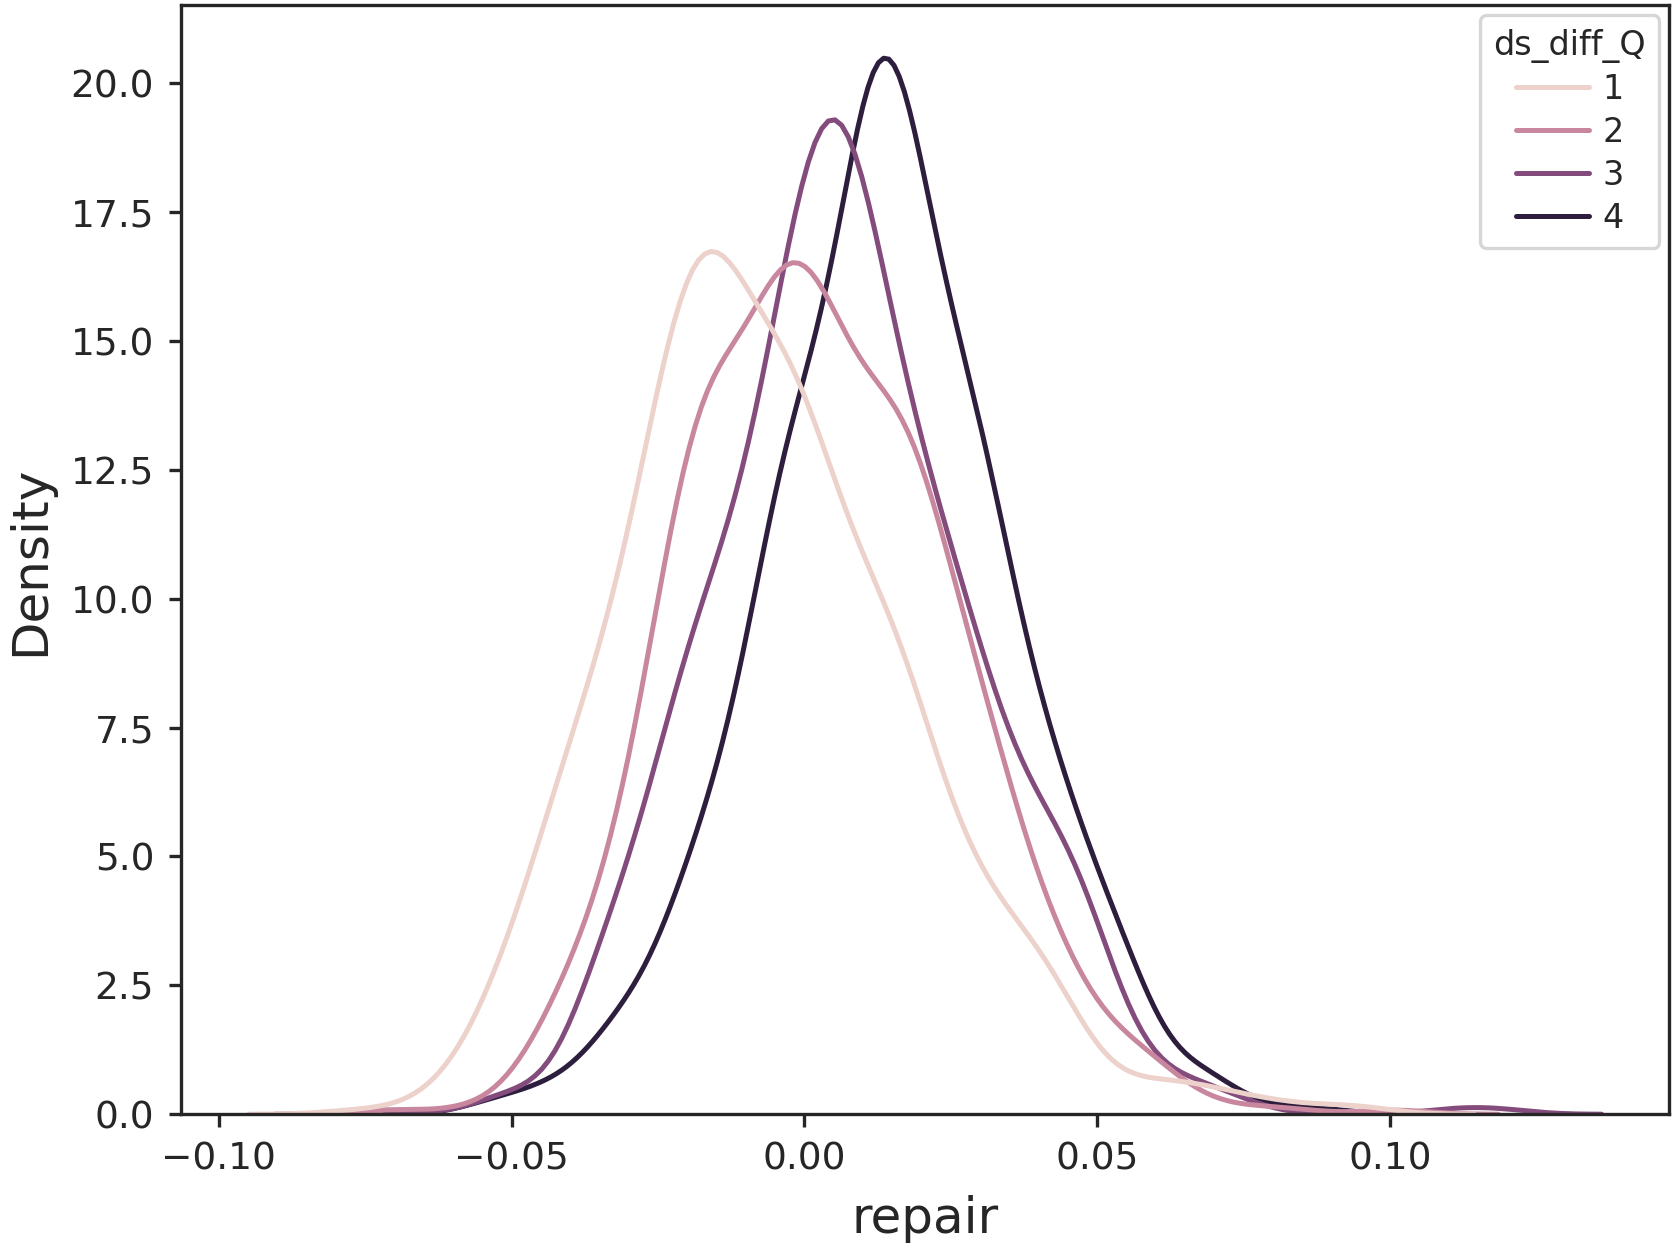

In [ ]:
import bbi
ds_stack_0h = bbi.stackup(
    ds_dict_obs['wt_nouv_ds'][0],
    tads.chrom,
    tads.start,
    tads.end,
    bins=1,
)

ds_stack_3h = bbi.stackup(
    ds_dict_obs['wt_3h_ds'][0],
    tads.chrom,
    tads.start,
    tads.end,
    bins=1,
)

tads_features = tads.copy()
tads_features['ds_signal'] = ds_stack_0h.flatten()
tads_features['repair'] = ds_stack_0h.flatten() - ds_stack_3h.flatten()
sns.kdeplot(data=tads_features, x='repair', hue='ds_diff_Q', common_norm=False)